### Libraries.

In [12]:
import math
import os
import os
import sys
from typing import Literal, OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.special import softmax
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, roc_curve, auc
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
import torch
from tqdm import tqdm

from sc_exp_design.constants import DataFields, LossFields, ParamsFields
from sc_exp_design.data import DataManager, SequentialDataLoader
from sc_exp_design.networks import ConditionEncoder, MLPBlock, MLPGaussianNoiseModel
from sc_exp_design.training import TargetPredictionTrainer
from sc_exp_design.training.callbacks import BaseCallBack
from sc_exp_design.utils import set_reproducibility

sys.path.insert(0, "../scripts")
from fetch_data import get_log_transformed_experimental_variables
from data_utils import (
    get_one_hot_encoded_protocols,
    get_one_hot_encoded_protocol_axis
)

sys.path.insert(0, "../")
from forward_model import TargetPredictionModel



### Paths and constants.


In [2]:
# working locally?
IS_RUN_LOCALLY = False

# paths
if IS_RUN_LOCALLY:
    H5AD_PATH = "/Users/lorenzo.consoli/Work/data/collab-goettgens/ds_HID01_logicle_100k_UMAP_ann.h5ad"
else:
    H5AD_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"

# columns
EXPERIMENTAL_COLUMNS = [
    'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]',
    'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]',
    'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]'
]
SCATTER_COLUMNS = ['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width']
LOG1P_EXP_COL = ["um171_[nm]", "um729_[µm]", "scf_[ng_ml]", 
                 "butyzamide_[nm]", "o2_[%]",
                 "sr1_[nm]", "mtg_[µm]", "rhflt3l_[ng_ml]", "gm-csf_[ng_ml]"]
LOG21P_EXP_COL = ["ldl_[ng_ml]", "il3_[ng_ml]", "retinoic_acid_[µm]",]

# adata keys
X_CHANNEL_OBSM_KEY = "X_channel"
X_SCATTER_OBSM_KEY = "X_scatter"
OHE_PROTOCOLS_OBS_KEY = "protocol"
OHE_PROTOCOLS_UNS_KEY = "protocol_ohe"
CONCAT_FEATS_OBSM_KEY_SUFFIX = "scatter_concat"
CONDITION_CONCAT_OBSM_KEY = "protocol_axes_concat"
TARGET_OBS_KEY = "cell_type"


# transformations options
STANDARDIZE_SCATTER_FEATURES = True
STANDARDIZE_CHANNEL_FEATURES = True
STANDARDIZE_PCs = False

# training
TRAIN_BATCH_SIZE = 1024
VAL_BATCH_SIZE = 64
LR = 1e-3
NUM_GRAD_STEPS = 1_000
GRAD_STEPS_LOG_INTERVAL = 10

# model
STATE_ENCODER_HIDDEN_DIMS = (128, 128)
DEVICE = "cpu"

# reproducibility
SEED = 42
set_reproducibility(SEED)


### Reading adata.

In [3]:
adata = sc.read_h5ad(H5AD_PATH)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

### Label encoder for target.

In [4]:
le_cell_type = LabelEncoder()
le_cell_type.fit(adata.obs["cell_type"].values)


LabelEncoder()

### Handling conditions.

In [5]:
# concatenated experimental variable
adata = get_log_transformed_experimental_variables(
    adata,
    EXPERIMENTAL_COLUMNS,
    LOG1P_EXP_COL,
    LOG21P_EXP_COL,
    CONDITION_CONCAT_OBSM_KEY
)

# one hot encoding of concatenated protocol axes
adata = get_one_hot_encoded_protocols(
    adata,
    EXPERIMENTAL_COLUMNS,
    OHE_PROTOCOLS_OBS_KEY,
    OHE_PROTOCOLS_UNS_KEY
)


# one hot encoding of concatenated protocol axes
adata = get_one_hot_encoded_protocol_axis(
    adata,
    EXPERIMENTAL_COLUMNS,
    OHE_PROTOCOLS_UNS_KEY
)
adata


AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type', 'protocol'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'protocol_ohe', 'mtg_[µm]_protocol_ohe', 'rhflt3l_

### Splitting the data.

In [6]:
train_adata, val_adata = train_test_split(adata, test_size=0.3)
train_adata.shape, val_adata.shape

((70000, 21), (30000, 21))

### Creating representation with concatenated scatter features and normalizing features.


In [7]:
# retrieving scatter features and optionally normalizing them
X_scatter_train = train_adata.obs[SCATTER_COLUMNS].values
X_scatter_val =  val_adata.obs[SCATTER_COLUMNS].values
X_scatter_mean = X_scatter_train.mean(0)
X_scatter_std = X_scatter_train.std(0)
if STANDARDIZE_SCATTER_FEATURES:
    print("Standardizing scatter features")
    X_scatter_train = (X_scatter_train - X_scatter_mean)/X_scatter_std
    X_scatter_val = (X_scatter_val - X_scatter_mean)/X_scatter_std
assert np.isfinite(X_scatter_train).all()
assert np.isfinite(X_scatter_val).all()
# retrieving scatter features and optionally normalizing them
train_adata.obsm[X_SCATTER_OBSM_KEY] = X_scatter_train
val_adata.obsm[X_SCATTER_OBSM_KEY] = X_scatter_val


# concatenating with channel features
train_adata.obsm[X_CHANNEL_OBSM_KEY] = train_adata.X
val_adata.obsm[X_CHANNEL_OBSM_KEY] = val_adata.X
X_channel_train = train_adata.X
X_channel_val = val_adata.X
X_channel_mean = X_channel_train.mean(0)
X_channel_std = X_channel_train.std(0)
if STANDARDIZE_CHANNEL_FEATURES:
    print("Standardizing channel features")
    X_channel_train = (X_channel_train - X_channel_mean)/X_channel_std
    X_channel_val = (X_channel_val - X_channel_mean)/X_channel_std
assert np.isfinite(X_channel_train).all()
assert np.isfinite(X_channel_val).all()

train_adata.X = X_channel_train
val_adata.X = X_channel_val
train_adata.obsm[f"X_channel_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_channel_train, X_scatter_train), axis=1)
val_adata.obsm[f"X_channel_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_channel_val, X_scatter_val), axis=1)

# concatenating with PCs
X_pca_train = train_adata.obsm["X_pca"]
X_pca_val = val_adata.obsm["X_pca"]
X_pca_mean = X_pca_train.mean(0)
X_pca_std = X_pca_train.std(0)
if STANDARDIZE_PCs:
    print("Standardizing PCs")
    X_pca_train = (X_pca_train - X_pca_mean)/X_pca_std
    X_pca_val = (X_pca_val - X_pca_mean)/X_pca_std
assert np.isfinite(X_pca_train).all()
assert np.isfinite(X_pca_val).all()

train_adata.obsm["X_pca"] = X_pca_train
val_adata.obsm["X_pca"] = X_pca_val
train_adata.obsm[f"X_pca_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_pca_train, X_scatter_train), axis=1)
val_adata.obsm[f"X_pca_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_pca_val, X_scatter_val), axis=1)
train_adata, val_adata

Standardizing scatter features
Standardizing channel features


/tmp/ipykernel_2347552/3366577033.py:13: ImplicitModificationWarning: Setting element `.obsm['X_scatter']` of view, initializing view as actual.
  train_adata.obsm[X_SCATTER_OBSM_KEY] = X_scatter_train
/tmp/ipykernel_2347552/3366577033.py:14: ImplicitModificationWarning: Setting element `.obsm['X_scatter']` of view, initializing view as actual.
  val_adata.obsm[X_SCATTER_OBSM_KEY] = X_scatter_val


(AnnData object with n_obs × n_vars = 70000 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type', 'protocol'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'protocol_ohe', 'mtg_[µm]_protocol_ohe', 'rhflt

### Defining the data managers.

In [16]:
# initializing data managers
dm_dict = {}
# reprs = ["X_channel", "X_pca", f"X_channel_{CONCAT_FEATS_OBSM_KEY_SUFFIX}", f"X_pca_{CONCAT_FEATS_OBSM_KEY_SUFFIX}", X_SCATTER_OBSM_KEY]
reprs = ["X_channel",]
for repr in reprs:
    dm = DataManager(
        train_adata,
        None if repr == "X_channel" else repr,
        load_target_covariates=True,
        target_covariates={"cell_type": "label"},
    )
    dm_dict[repr] = dm
dm_dict.keys()

dict_keys(['X_channel'])

### Retrieving train and validation data.


In [ ]:
data_dict = {
    data_mode: {
        "train": dm.get_data(train_adata),
        "val": dm.get_data(val_adata)
    }
    for data_mode, dm in dm_dict.items()
}
target_dim = list(data_dict.values())[0]["train"].data.target_data[TARGET_OBS_KEY].max() +1 
target_dim

np.int64(19)

Loss: 0.3147:  84%|████████▍ | 840/1000 [02:17<00:04, 35.89it/s]

### Settings for NN.

In [18]:
get_mlp_config = lambda hidden_dims, final_activation_class=torch.nn.Identity: {
    "hidden_dims": hidden_dims,
    "use_batchnorm": False,
    "use_dropout": False,
    "activation_class": torch.nn.ReLU,
    "final_activation_class": final_activation_class,
}
get_lm_config = lambda final_activation_class=torch.nn.Identity: get_mlp_config((), final_activation_class=final_activation_class)



### Initializing models and trainers.

In [19]:
USE_CLASS_WEIGHTS = False
solver = "lbfgs" # The solver used for the optimization, default to lbfgs
penalty = "elasticnet" if solver == "saga" else "l2" # Applied regularization, default "l2"
tol = 1e-4 # Tolerance for the solver, default 1e-4
C = 1.0 # Regularization strength, default 1.0
max_iter = 1_000 # Number iterations for solver, default to 100
class_weight= "balanced" if USE_CLASS_WEIGHTS else None # Whether to use balanced class weights, default to None
l1_ratio = 5e-1 if penalty == "elasticnet" else None # the ration for L1 penalty in elasticnet, default to None


In [20]:
mlp_dict = {}
lm_dict = {}
lm_sklearn_dict = {}
for idx, (data_mode, dl) in enumerate(data_dict.items()):
    # info message
    print(f"Fitting model {data_mode} ({idx}/{len(data_dict)})")
    train_data = dl["train"]
    state_dim = train_data.data.state_data.shape[-1]

    optimizer_cls = torch.optim.Adam

    # mlp
    mlp_cfg = get_mlp_config(STATE_ENCODER_HIDDEN_DIMS)
    mlp = TargetPredictionModel(
        state_dim,
        device_id=DEVICE,
    )
    mlp.prepare_target_prediction_model(
        (TARGET_OBS_KEY, ),
        {TARGET_OBS_KEY: target_dim},
        target_covariates_predictor_kwargs={
            TARGET_OBS_KEY: mlp_cfg
        },
        optimizer_class=optimizer_cls
    )
    mlp.train_target_prediction_model(
        train_data,
        num_training_steps=NUM_GRAD_STEPS,
        train_batch_size=TRAIN_BATCH_SIZE,
    )
    mlp_dict[data_mode] = mlp

    # lm torch
    lm_cfg = get_lm_config()
    lm = TargetPredictionModel(
        state_dim,
        device_id=DEVICE,
    )
    lm.prepare_target_prediction_model(
        (TARGET_OBS_KEY, ),
        {TARGET_OBS_KEY: target_dim},
        target_covariates_predictor_kwargs={
            TARGET_OBS_KEY: lm_cfg
        },
        optimizer_class=optimizer_cls
    )
    lm.train_target_prediction_model(
        train_data,
        num_training_steps=NUM_GRAD_STEPS,
        train_batch_size=TRAIN_BATCH_SIZE,
    )
    lm_dict[data_mode] = lm

    # lm sklearn
    X_train = train_data.state_data
    Y_train = train_data.target_data["cell_type"]
    lm = LogisticRegression(
        solver=solver,
        penalty=penalty,
        tol=tol,
        C=C,
        class_weight=class_weight,
        l1_ratio=l1_ratio,
    )
    lm.fit(X_train, Y_train)
    lm_sklearn_dict[data_mode] = lm


Fitting model X_channel (0/1)


Loss: 0.9286: 100%|██████████| 1000/1000 [00:36<00:00, 27.40it/s]


### Defining function for evaluating classifier.

In [21]:
# train data
def evaluate_classifier(
    model, data
):
    X = data.state_data
    Y = data.target_data["cell_type"]
    Y_labels = data.adata.obs["cell_type"].values
    if isinstance(model, LogisticRegression):
        Y_pred_probs = lm.predict_proba(X)
        Y_pred_id = lm.predict(X)
        Y_pred_label = le_cell_type.inverse_transform(Y_pred_id)
    else:
        X = torch.from_numpy(X).type(torch.float32).to(DEVICE)
        Y_logits = model(X)["cell_type"].detach().cpu().numpy()
        Y_pred_probs = softmax(Y_logits, axis=-1)
        Y_pred_id = np.argmax(Y_pred_probs, axis=-1)
        Y_pred_label = le_cell_type.inverse_transform(Y_pred_id)

    cm = confusion_matrix(
        Y_labels,
        Y_pred_label,
        labels=le_cell_type.classes_,
    )
    accuracy = accuracy_score(Y, Y_pred_id)
    precision = precision_score(Y, Y_pred_id, average="weighted")
    recall = recall_score(Y, Y_pred_id, average="weighted")
    f1 = f1_score(Y, Y_pred_id, average="weighted")
    report = classification_report(Y, Y_pred_id, target_names=le_cell_type.classes_, output_dict=True)
    y_true_bin = label_binarize(
        [np.where(le_cell_type.classes_ == c)[0][0] for c in Y_labels], classes=range(len(le_cell_type.classes_))
    )
    classes_roc_auc = {}
    classes_fpr = {}
    classes_tpr = {}
    for i, class_label in enumerate(le_cell_type.classes_):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], Y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        classes_roc_auc[class_label] = roc_auc
        classes_fpr[class_label] = fpr
        classes_tpr[class_label] = tpr
        # report[class_label]["tpr"] = tpr
        # report[class_label]["fpr"] = fpr
        report[class_label]["roc_auc"] = roc_auc
    macro_roc_auc = roc_auc_score(y_true_bin, Y_pred_probs, average="macro")
    micro_roc_auc = roc_auc_score(y_true_bin, Y_pred_probs, average="micro")
    return {
        "cm": cm,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "report": report,
        "classes_roc_auc": classes_roc_auc,
        "classes_tpr": classes_tpr,
        "classes_fpr": classes_fpr,
        "micro_roc_auc": micro_roc_auc,
        "macro_roc_auc": macro_roc_auc,
    }

def display_cm(cm, title):
    fig, axes = plt.subplots(figsize=(7, 7))
    val_cmd = ConfusionMatrixDisplay(
        cm,
        display_labels=le_cell_type.classes_,
    )
    val_cmd.plot(ax=axes)
    axes.tick_params("x", rotation=90, size=8)
    axes.set_title(f"Confusion matrix {title}")
    return fig, axes



### Computing metrics for each classifier.

In [23]:
eval_dict = {}
for idx, (data_mode, data) in enumerate(data_dict.items()):
    # info message
    print(f"Evaluating model {data_mode} ({idx}/{len(data_dict)})")
    eval_dict[f"{data_mode}_mlp"] = evaluate_classifier(mlp_dict[data_mode].target_prediction_model, data["val"])
    eval_dict[f"{data_mode}_lm"] = evaluate_classifier(lm_dict[data_mode].target_prediction_model, data["val"])
    eval_dict[f"{data_mode}_lm_sklearn"] = evaluate_classifier(lm_sklearn_dict[data_mode], data["val"])

Evaluating model X_channel (0/1)



=== Combined Evaluation Summary ===
    data_mode model                 class  accuracy  precision    recall  \
0   X_channel   mlp                GLOBAL    0.8825   0.882987  0.882500   
1   X_channel   mlp             CD14-Mono       NaN   0.839917  0.773946   
2   X_channel   mlp         CD49c-Myeloid       NaN   0.884577  0.874875   
3   X_channel   mlp    CyclingProgenitor*       NaN   0.961440  0.949239   
4   X_channel   mlp              DCs-CD14       NaN   1.000000  0.850000   
5   X_channel   mlp              EarlyGMP       NaN   0.893805  0.597633   
6   X_channel   mlp           Early_Pro-B       NaN   0.895604  0.802956   
7   X_channel   mlp        EosBasoMastPre       NaN   0.894207  0.918737   
8   X_channel   mlp      EosBasoMastPre_2       NaN   0.845541  0.837539   
9   X_channel   mlp                EryPro       NaN   0.962842  0.939232   
10  X_channel   mlp             GMP-Cycle       NaN   0.823347  0.893330   
11  X_channel   mlp            GMP-Neutro       NaN

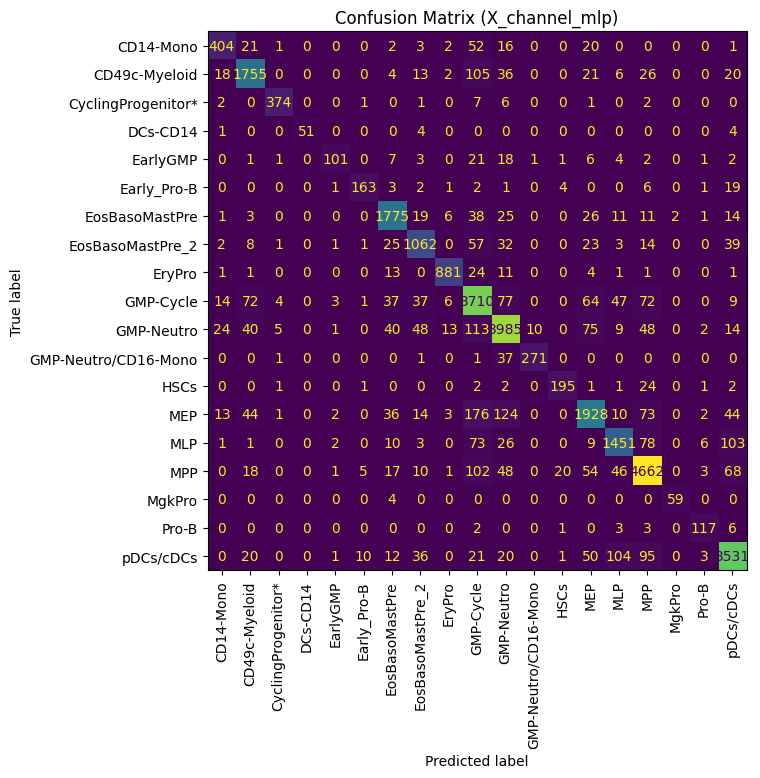

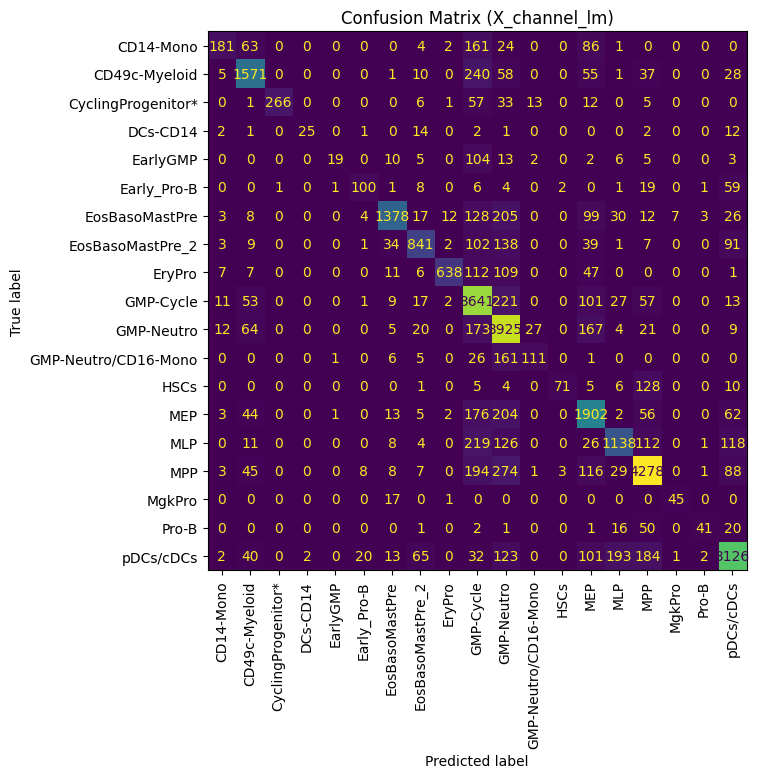

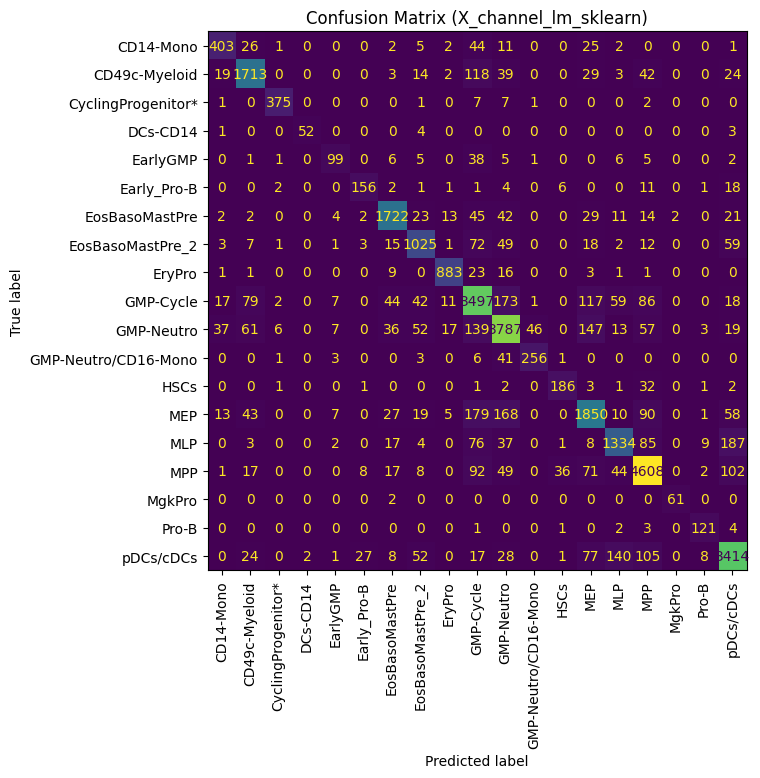

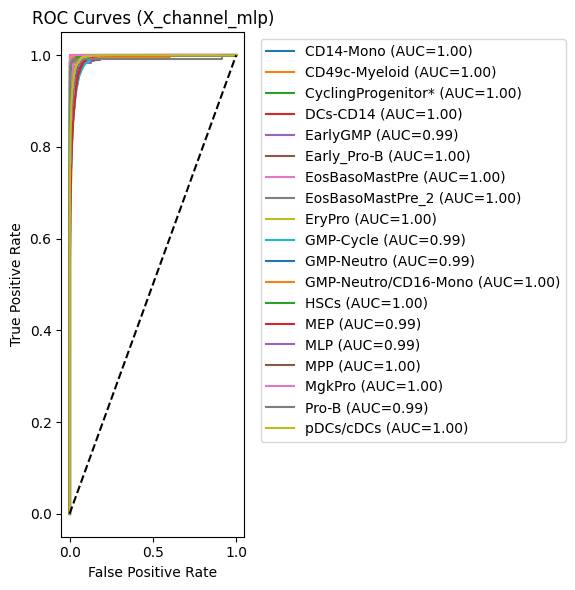

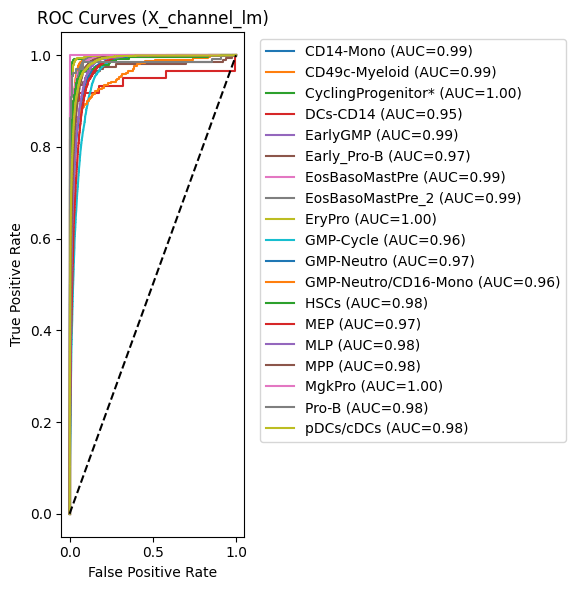

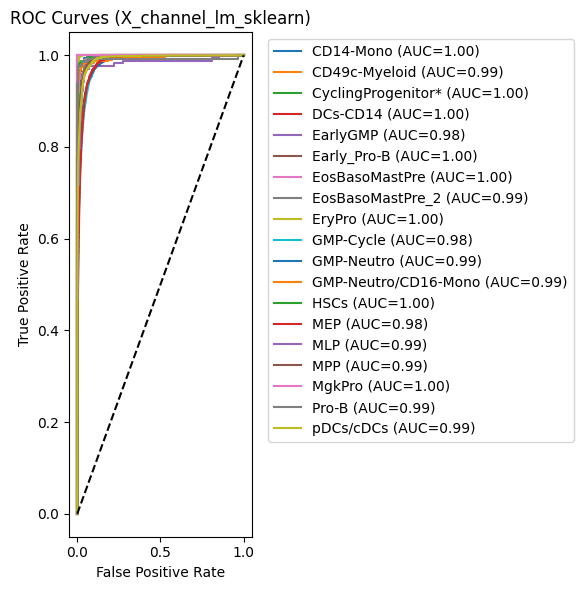

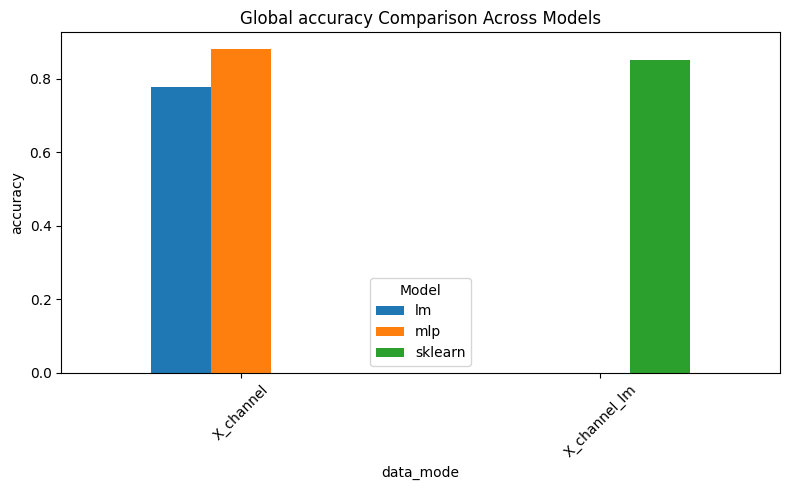

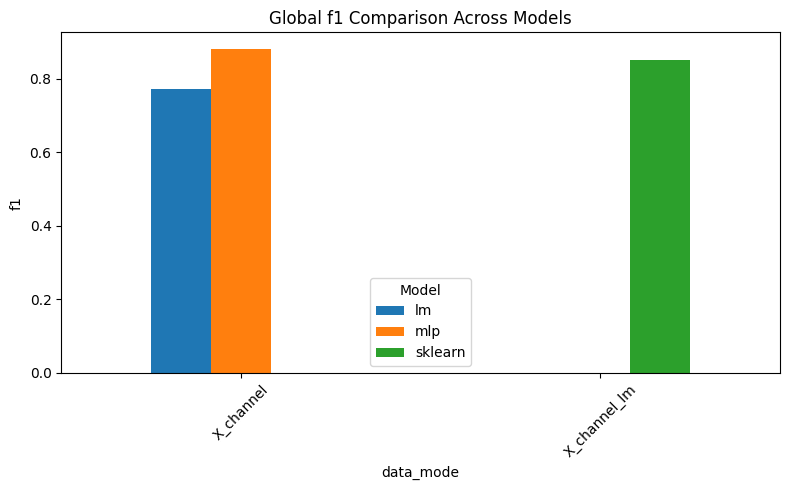

Loss: 0.3147:  84%|████████▍ | 840/1000 [05:15<01:00,  2.66it/s]


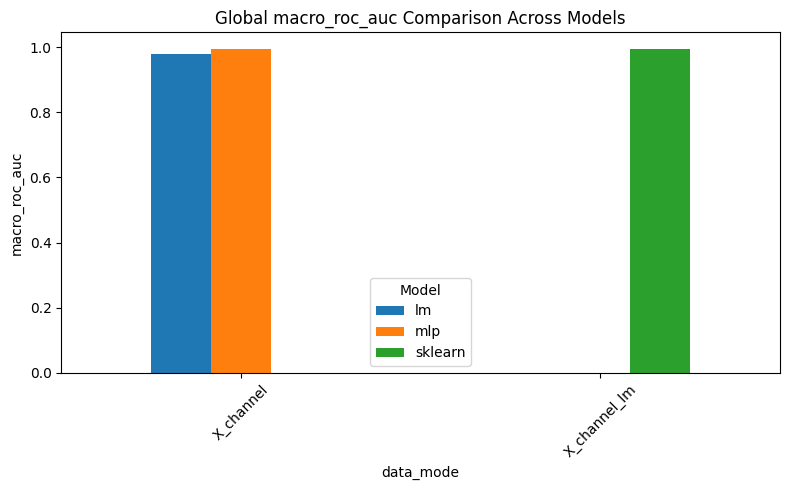

In [24]:

# ---- Step 2: Convert eval_dict into a tidy DataFrame ----
def make_combined_eval_dataframe(eval_dict):
    rows = []
    for key, metrics in eval_dict.items():
        data_mode, model_name = key.rsplit("_", 1)  # split key into parts
        # global metrics
        rows.append({
            "data_mode": data_mode,
            "model": model_name,
            "class": "GLOBAL",
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "macro_roc_auc": metrics["macro_roc_auc"],
            "micro_roc_auc": metrics["micro_roc_auc"]
        })
        # per-class metrics
        for cls, cls_metrics in metrics["report"].items():
            if cls in ["accuracy", "macro avg", "weighted avg"]:
                continue
            rows.append({
                "data_mode": data_mode,
                "model": model_name,
                "class": cls,
                "precision": cls_metrics["precision"],
                "recall": cls_metrics["recall"],
                "f1": cls_metrics["f1-score"],
                "support": cls_metrics["support"],
                "roc_auc": cls_metrics["roc_auc"]
            })
    return pd.DataFrame(rows)

eval_df = make_combined_eval_dataframe(eval_dict)

# ---- Step 3: Display top of the DataFrame ----
print("\n=== Combined Evaluation Summary ===")
print(eval_df.head(20))


# ---- Step 4: Plot confusion matrices for all ----
def plot_all_confusion_matrices(eval_dict):
    for key, metrics in eval_dict.items():
        fig, ax = plt.subplots(figsize=(7, 7))
        ConfusionMatrixDisplay(
            metrics["cm"], 
            display_labels=le_cell_type.classes_
        # ).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
        ).plot(ax=ax, values_format="d", colorbar=False)
        ax.set_title(f"Confusion Matrix ({key})")
        plt.xticks(rotation=90)
        plt.show()

# ---- Step 5: Plot ROC curves for all ----
def plot_all_roc_curves(eval_dict):
    for key, metrics in eval_dict.items():
        plt.figure(figsize=(6, 6))
        for cls, auc_val in metrics["classes_roc_auc"].items():
            plt.plot(
                metrics["classes_fpr"][cls],
                metrics["classes_tpr"][cls],
                label=f"{cls} (AUC={auc_val:.2f})"
            )
        plt.plot([0, 1], [0, 1], "k--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curves ({key})")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

# ---- Step 6: Global metric comparison (bar plots) ----
def plot_global_metric_comparison(eval_df, metric="accuracy"):
    global_df = eval_df[eval_df["class"] == "GLOBAL"]
    pivot_df = global_df.pivot(index="data_mode", columns="model", values=metric)

    pivot_df.plot(kind="bar", figsize=(8, 5))
    plt.ylabel(metric)
    plt.title(f"Global {metric} Comparison Across Models")
    plt.xticks(rotation=45)
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()


# ---- Run plots ----
plot_all_confusion_matrices(eval_dict)
plot_all_roc_curves(eval_dict)
plot_global_metric_comparison(eval_df, metric="accuracy")
plot_global_metric_comparison(eval_df, metric="f1")
plot_global_metric_comparison(eval_df, metric="macro_roc_auc")


In [25]:
eval_df.to_csv("classification_results.csv")

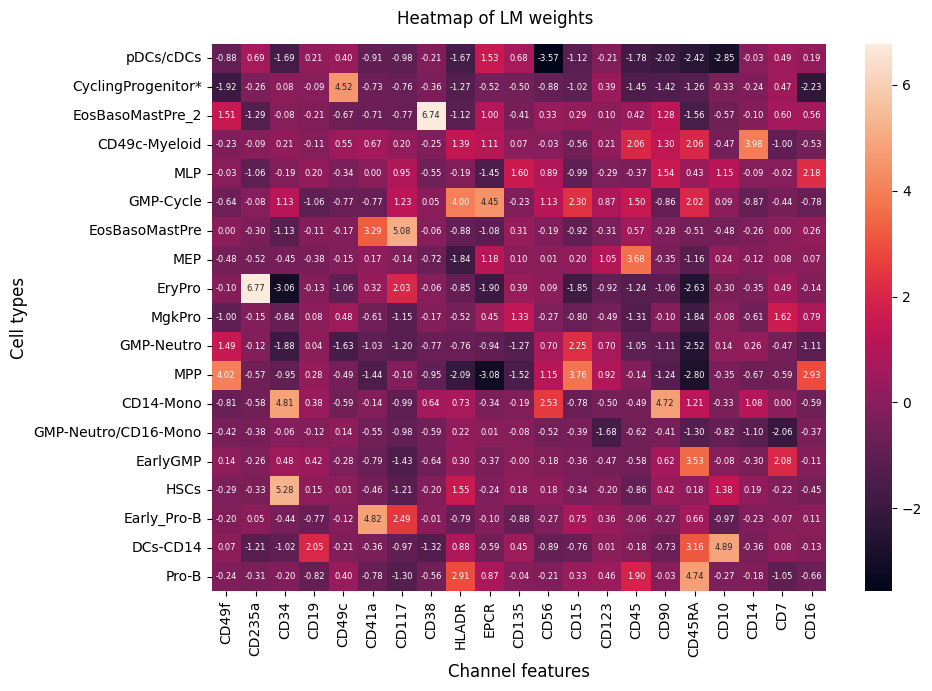

In [34]:
def visualize_lm_weights(W):
    yticklabels = adata.obs.cell_type.unique()
    xticklabels = adata.var_names

    fig, axes = plt.subplots(figsize=(10, 7))
    fig.suptitle("Heatmap of LM weights")
    sns.heatmap(
        W,
        yticklabels=yticklabels,
        xticklabels=xticklabels,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 6},
        ax=axes,
    )
    axes.set_xlabel("Channel features", fontsize=12)
    axes.set_ylabel("Cell types", fontsize=12)

    fig.tight_layout()
    fig.show()
# visualize_lm_weights(lm)

visualize_lm_weights(lm_sklearn_dict[data_mode].coef_ )

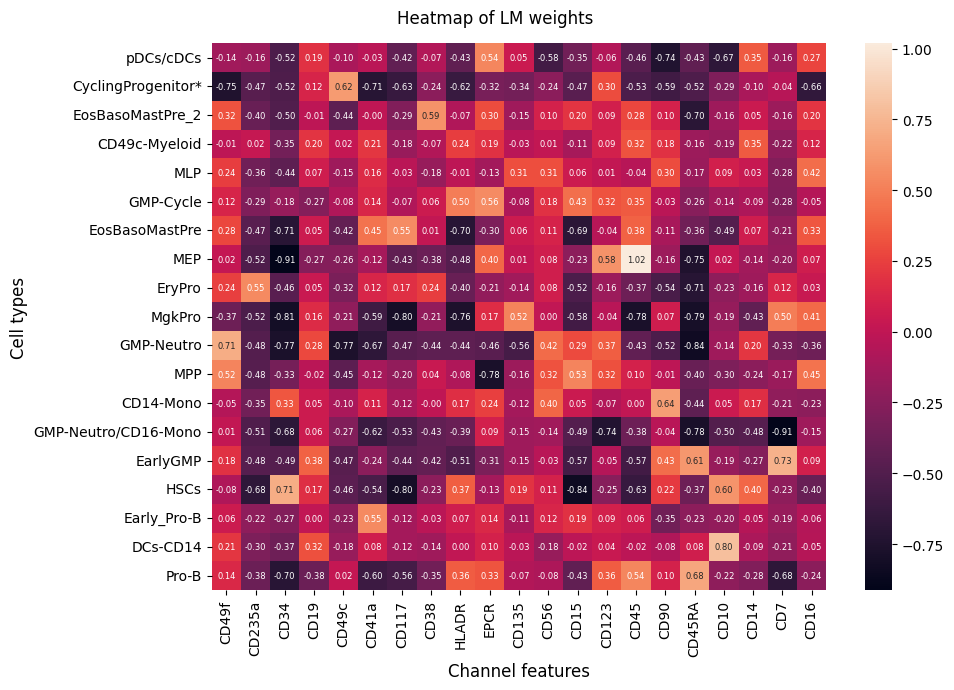

In [35]:
W = next(iter(lm_dict[data_mode].target_prediction_model.parameters())).detach().cpu().numpy()
visualize_lm_weights(W)